In [ ]:
!wget https://raw.githubusercontent.com/byuidatascience/data4python4ds/master/data-raw/flights/flights.csv
!wget https://raw.githubusercontent.com/ismayc/nycflights13/master/data-raw/airlines.csv
!wget https://raw.githubusercontent.com/ismayc/nycflights13/master/data-raw/airports.csv

--2026-04-27 06:27:39--  https://raw.githubusercontent.com/byuidatascience/data4python4ds/master/data-raw/flights/flights.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31053850 (30M) [text/plain]
Saving to: ‘flights.csv’

flights.csv         100%[===================>]  29.62M   191MB/s    in 0.2s    

2026-04-27 06:27:40 (191 MB/s) - ‘flights.csv’ saved [31053850/31053850]

--2026-04-27 06:27:40--  https://raw.githubusercontent.com/ismayc/nycflights13/master/data-raw/airlines.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Lengt

In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Flight Data Analysis") \
    .getOrCreate()

In [ ]:
flights = spark.read.csv("flights.csv", header=True, inferSchema=True)
airlines = spark.read.csv("airlines.csv", header=True, inferSchema=True)
airports = spark.read.csv("airports.csv", header=True, inferSchema=True)

flights.show(5)

+----+-----+---+--------+--------------+---------+--------+--------------+---------+-------+------+-------+------+----+--------+--------+----+------+-------------------+
|year|month|day|dep_time|sched_dep_time|dep_delay|arr_time|sched_arr_time|arr_delay|carrier|flight|tailnum|origin|dest|air_time|distance|hour|minute|          time_hour|
+----+-----+---+--------+--------------+---------+--------+--------------+---------+-------+------+-------+------+----+--------+--------+----+------+-------------------+
|2013|    1|  1|     517|           515|        2|     830|           819|       11|     UA|  1545| N14228|   EWR| IAH|     227|    1400|   5|    15|2013-01-01 10:00:00|
|2013|    1|  1|     533|           529|        4|     850|           830|       20|     UA|  1714| N24211|   LGA| IAH|     227|    1416|   5|    29|2013-01-01 10:00:00|
|2013|    1|  1|     542|           540|        2|     923|           850|       33|     AA|  1141| N619AA|   JFK| MIA|     160|    1089|   5|    40|2

In [ ]:
flights.createOrReplaceTempView("flights_view")

In [ ]:
flights.columns

['year',
 'month',
 'day',
 'dep_time',
 'sched_dep_time',
 'dep_delay',
 'arr_time',
 'sched_arr_time',
 'arr_delay',
 'carrier',
 'flight',
 'tailnum',
 'origin',
 'dest',
 'air_time',
 'distance',
 'hour',
 'minute',
 'time_hour',
 'gain']

In [ ]:
flights.printSchema()

root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- dep_time: string (nullable = true)
 |-- sched_dep_time: integer (nullable = true)
 |-- dep_delay: double (nullable = true)
 |-- arr_time: string (nullable = true)
 |-- sched_arr_time: integer (nullable = true)
 |-- arr_delay: double (nullable = true)
 |-- carrier: string (nullable = true)
 |-- flight: integer (nullable = true)
 |-- tailnum: string (nullable = true)
 |-- origin: string (nullable = true)
 |-- dest: string (nullable = true)
 |-- air_time: string (nullable = true)
 |-- distance: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- minute: integer (nullable = true)
 |-- time_hour: timestamp (nullable = true)
 |-- gain: double (nullable = true)



In [ ]:
from pyspark.sql.functions import col

flights = flights.filter(
    (col("dep_delay").isNotNull()) &
    (col("arr_delay").isNotNull())
)

In [ ]:
flights = flights.replace("NA", None)

In [ ]:
from pyspark.sql.functions import expr

# Use try_cast (handles NA safely)
flights = flights.withColumn("dep_delay_num", expr("try_cast(dep_delay as double)"))
flights = flights.withColumn("arr_delay_num", expr("try_cast(arr_delay as double)"))

# Keep only valid numeric rows
flights = flights.filter(
    "dep_delay_num IS NOT NULL AND arr_delay_num IS NOT NULL"
)

# Create gain
flights = flights.withColumn("gain", expr("dep_delay_num - arr_delay_num"))

In [ ]:
flights.createOrReplaceTempView("flights_view")

In [ ]:
flights = spark.read.csv(
    "flights.csv",
    header=True,
    inferSchema=True,
    nullValue="NA"   # 🔥 THIS IS THE KEY FIX
)

In [ ]:
from pyspark.sql.functions import col

# remove nulls
flights = flights.filter(
    col("dep_delay").isNotNull() &
    col("arr_delay").isNotNull()
)

# create gain
flights = flights.withColumn(
    "gain", col("dep_delay") - col("arr_delay")
)

In [ ]:
flights.createOrReplaceTempView("flights_view")

In [ ]:
result = spark.sql("""
SELECT carrier, AVG(gain) as avg_gain
FROM flights_view
GROUP BY carrier
ORDER BY avg_gain DESC
""")

result.show()

+-------+-------------------+
|carrier|           avg_gain|
+-------+-------------------+
|     AS|  15.76163610719323|
|     HA|  11.81578947368421|
|     VX| 10.992181391712275|
|     9E|   9.05990516942292|
|     UA|  8.458897234432868|
|     AA|   8.20483926503271|
|     WN|  8.012537363002325|
|     DL|  7.579608879936212|
|     EV|  4.042498239023245|
|     B6|  3.509574645229329|
|     YV| 3.3419117647058822|
|     US| 1.6150975745045635|
|     OO| 0.6551724137931034|
|     MQ|-0.3293525582138435|
|     FL|-1.5099212598425198|
|     F9|-1.7195301027900147|
+-------+-------------------+



In [ ]:
pdf = result.toPandas()

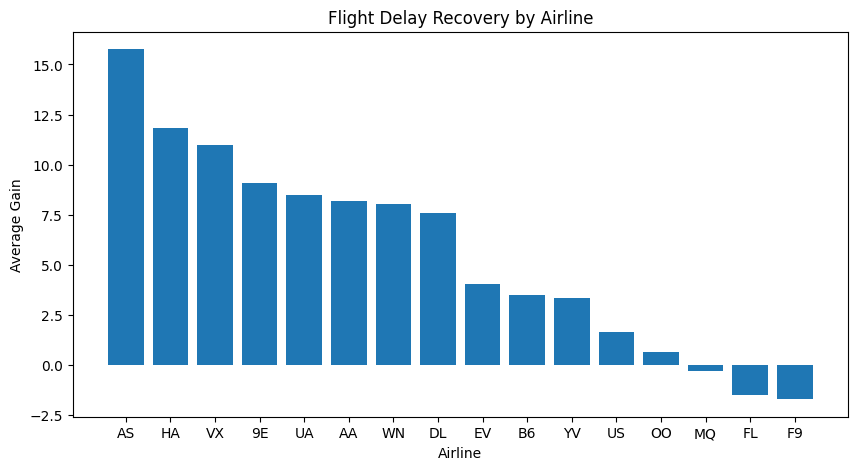

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(pdf['carrier'], pdf['avg_gain'])

plt.xlabel("Airline")
plt.ylabel("Average Gain")
plt.title("Flight Delay Recovery by Airline")

plt.show()

In [ ]:
spark.sql("""
SELECT distance, AVG(gain) as avg_gain
FROM flights_view
GROUP BY distance
ORDER BY distance
LIMIT 20
""").show()

+--------+-------------------+
|distance|           avg_gain|
+--------+-------------------+
|      80|              2.375|
|      94|  4.454748603351955|
|      96|-2.5953177257525084|
|     116| 10.672330097087379|
|     143|   9.05023923444976|
|     160| 5.5307262569832405|
|     169|  3.385496183206107|
|     173| 7.1761904761904765|
|     184| 2.8584466019417474|
|     185| 11.066666666666666|
|     187|  6.651654252554997|
|     195| 5.8858267716535435|
|     198|  9.895910780669144|
|     199|-0.0638995084653195|
|     200|  7.691442729178578|
|     209|  5.158790170132325|
|     212| 3.4076539101497505|
|     213|  4.756827048114435|
|     214|-0.9691136974037601|
|     228|  2.931800158604282|
+--------+-------------------+



In [ ]:
spark.sql("""
SELECT carrier, AVG(gain) as avg_gain
FROM flights_view
GROUP BY carrier
ORDER BY avg_gain DESC
LIMIT 5
""").show()

+-------+------------------+
|carrier|          avg_gain|
+-------+------------------+
|     AS| 15.76163610719323|
|     HA| 11.81578947368421|
|     VX|10.992181391712275|
|     9E|  9.05990516942292|
|     UA| 8.458897234432868|
+-------+------------------+



In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["distance", "dep_delay"],
    outputCol="features"
)

data = assembler.transform(flights).select("features", "gain")

In [ ]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(featuresCol="features", labelCol="gain")
model = lr.fit(data)

print("Model Trained Successfully ✅")

Model Trained Successfully ✅


In [ ]:
predictions = model.transform(data)
predictions.select("features", "gain", "prediction").show(5)

+-------------+----+------------------+
|     features|gain|        prediction|
+-------------+----+------------------+
| [1400.0,2.0]|  -9| 6.747446058972455|
| [1416.0,4.0]| -16| 6.752101026197765|
| [1089.0,2.0]| -31|5.9542136720962375|
|[1576.0,-1.0]|  17|  7.25058089873013|
| [762.0,-6.0]|  19| 5.264789566061734|
+-------------+----+------------------+
only showing top 5 rows


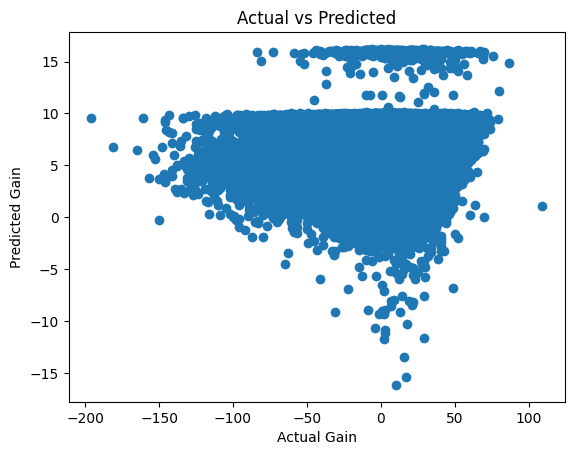

In [ ]:
pdf_pred = predictions.select("gain", "prediction").toPandas()

plt.scatter(pdf_pred['gain'], pdf_pred['prediction'])
plt.xlabel("Actual Gain")
plt.ylabel("Predicted Gain")
plt.title("Actual vs Predicted")
plt.show()